## Google Inc. (GOOG) — Sentiment Analysis & Correlation

### Overview
This notebook quantifies the relationship between financial news sentiment
and daily GOOG stock price returns. We apply VADER sentiment analysis to
news headlines, compute daily stock returns, and measure the statistical
correlation between the two using Pearson, Spearman and Kendall methods.

### Objectives
- Compare TextBlob vs VADER for financial headline sentiment analysis
- Align news publication dates to GOOG trading days
- Score each headline using VADER sentiment analysis
- Aggregate daily sentiment scores
- Compute daily stock returns
- Measure correlation between sentiment and returns
- Visualize and interpret the relationship



**We use VADER** because financial headlines are short, punchy, and often
use capitalization and punctuation for emphasis — exactly the context VADER
was designed for. TextBlob tends to classify too many financial headlines
as neutral, reducing sensitivity to meaningful sentiment shifts.

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon', quiet=True)

from src.data_loader import load_news_data, filter_by_stock, load_stock_data
from src.sentiment_analyzer import (
    score_headlines_vader,
    score_headlines_textblob,
    classify_sentiment,
    align_dates,
    aggregate_daily_sentiment,
    compute_daily_returns,
    merge_sentiment_returns,
    compute_correlation
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'serif'

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Data

We load both the financial news dataset and GOOG stock price data
using our modular data loading functions from src/data_loader.py.

In [3]:
# Load news data
df_news = load_news_data('../data/raw/raw_analyst_ratings.csv')

# Filter for GOOG
goog_news = filter_by_stock(df_news, 'GOOG')

# Load stock price data
goog_stock = load_stock_data('../data/raw/GOOG.csv')

print(f"\nNews articles  : {len(goog_news)}")
print(f"Stock records  : {len(goog_stock)}")
print(f"\nNews date range  : {goog_news['date'].min().date()} to {goog_news['date'].max().date()}")
print(f"Stock date range : {goog_stock['Date'].min().date()} to {goog_stock['Date'].max().date()}")

✅ Loaded 1407328 news articles.
✅ Found 1199 articles for GOOG.
✅ Loaded 3774 rows. No missing values.

News articles  : 1199
Stock records  : 3774

News date range  : 2018-11-13 to 2020-06-10
Stock date range : 2009-01-02 to 2023-12-29


## 3. TextBlob vs VADER Comparison

Before proceeding with our main analysis, we demonstrate the difference
between TextBlob and VADER on a sample of real GOOG headlines to justify
our tool selection.

In [4]:
# Sample 10 headlines for comparison
sample_headlines = goog_news['headline'].sample(10, random_state=42).tolist()

# Score with both tools
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()
comparison = []

for h in sample_headlines:
    vader_compound = sia.polarity_scores(h)['compound']
    tb_polarity = TextBlob(h).sentiment.polarity

    vader_label = classify_sentiment(vader_compound)
    tb_label = ('Positive' if tb_polarity > 0.1
                else 'Negative' if tb_polarity < -0.1
                else 'Neutral')

    comparison.append({
        'headline': h[:60] + '...' if len(h) > 60 else h,
        'vader_compound': round(vader_compound, 3),
        'vader_label': vader_label,
        'tb_polarity': round(tb_polarity, 3),
        'tb_label': tb_label,
        'agreement': '✅' if vader_label == tb_label else '❌'
    })

comp_df = pd.DataFrame(comparison)
print("=== TextBlob vs VADER Comparison ===")
print(comp_df.to_string(index=False))
print(f"\nAgreement rate: {(comp_df['agreement'] == '✅').sum()}/10")

=== TextBlob vs VADER Comparison ===
                                                       headline  vader_compound vader_label  tb_polarity tb_label agreement
YouTube Unit Of Alphabet Inc's Google Says Aims To Make All ...           0.202    Positive        0.125 Positive         ✅
Google CEO Sundar Pichai Was In Oklahoma To Announce A $600M...           0.318    Positive       -0.100  Neutral         ❌
Alphabet, Boeing Shares Get A Lift Following Earnings, While...           0.296    Positive        0.000  Neutral         ❌
Google Will Scrap Dutch, Irish IP Licensing System, Will Ret...           0.000     Neutral        0.000  Neutral         ✅
VMWare Announces Creation Of Next-Gen SOC Alliance With Splu...           0.542    Positive        0.000  Neutral         ❌
Rolling Along: Better Than Expected Earnings Continue Drivin...           0.440    Positive        0.217 Positive         ✅
WhatsApp Payments To Launch In India, BofA Says Monetization...           0.000     Neutral    

## 4. Date Alignment

We normalize news publication timestamps to UTC and align them to
the nearest GOOG trading day. Articles published on weekends or
market holidays are mapped to the next available trading day.
This ensures every news article is matched to a valid stock return.

In [5]:
# Align news dates to trading days
goog_news_aligned = align_dates(goog_news, goog_stock)

print(f"Total articles after alignment : {len(goog_news_aligned)}")

# Check for unmatched articles
unmatched = goog_news_aligned['trading_date'].isna().sum()
print(f"Unmatched articles             : {unmatched}")

print(f"\nSample of aligned dates:")
print(goog_news_aligned[
    ['date', 'date_only', 'trading_date', 'headline']
].head(10).to_string(index=False))

Total articles after alignment : 1199
Unmatched articles             : 0

Sample of aligned dates:
                     date  date_only trading_date                                                                                                                                                                                              headline
2020-06-10 19:25:13+00:00 2020-06-10   2020-06-10                                                                                                                             Facebook, Snap Analyst Projects Q2 Revenue Upside For Social Media Stocks
2020-06-10 17:18:50+00:00 2020-06-10   2020-06-10                                                                                                            How Cannabis Company Cannaphyll Is Marketing On Mass-Consumer Platforms, Google And Amazon
2020-06-10 04:28:00+00:00 2020-06-10   2020-06-10                                                                                                            

## 5. Sentiment Scoring with VADER

We apply VADER SentimentIntensityAnalyzer to each headline to compute
a compound sentiment score ranging from -1 (most negative) to +1 (most
positive). Each article is then classified as:
- **Positive** — compound score >= 0.05
- **Neutral**  — compound score between -0.05 and 0.05
- **Negative** — compound score <= -0.05

In [6]:
# Score headlines with VADER
goog_news_scored = score_headlines_vader(goog_news_aligned)

# Add sentiment label
goog_news_scored['sentiment_label'] = goog_news_scored['compound'].apply(
    classify_sentiment)

print("=== VADER Sentiment Score Statistics ===")
print(goog_news_scored['compound'].describe())
print(f"\nSentiment Distribution:")
print(goog_news_scored['sentiment_label'].value_counts())

goog_news_scored[['headline', 'compound',
                   'sentiment_label']].head(10)

=== VADER Sentiment Score Statistics ===
count    1199.000000
mean        0.080457
std         0.311855
min        -0.939300
25%         0.000000
50%         0.000000
75%         0.296000
max         0.947700
Name: compound, dtype: float64

Sentiment Distribution:
sentiment_label
Neutral     560
Positive    423
Negative    216
Name: count, dtype: int64


,headline,compound,sentiment_label
0,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",0.0000,Neutral
1,How Cannabis Company Cannaphyll Is Marketing O...,0.1779,Positive
2,"Twitter, Square Will Mark Juneteenth As Holida...",0.7096,Positive
3,Price Over Earnings Overview: Alphabet,0.0000,Neutral
4,Google Maps To Offer Relevant Local COVID-19 I...,0.0000,Neutral
5,"Starting This Week, Testing Center Alerts Will...",0.5423,Positive
6,CNBC Publishes Article Titled: States are Lean...,0.0000,Neutral
7,Congress Is Stepping Up Its Efforts To Kill Pa...,-0.6908,Negative
8,Twitter Takes Down Trump Campaign's Video Trib...,-0.5423,Negative
9,UPDATE: Chinese Government-Linked Hackers Rece...,0.0000,Neutral


### 5.1 Sentiment Distribution Visualization

The charts below show the distribution of compound sentiment scores
and the breakdown of positive, neutral and negative articles.

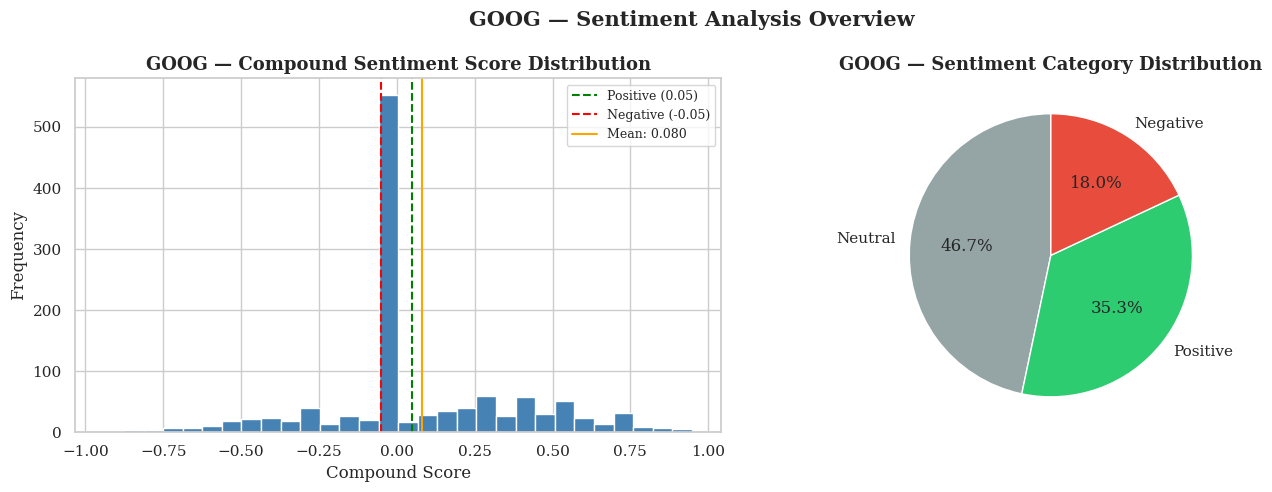

✅ Sentiment distribution plot rendered!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(goog_news_scored['compound'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].axvline(0.05,  color='green', linestyle='--',
                label='Positive (0.05)')
axes[0].axvline(-0.05, color='red',   linestyle='--',
                label='Negative (-0.05)')
axes[0].axvline(goog_news_scored['compound'].mean(),
                color='orange', linestyle='-',
                label=f"Mean: {goog_news_scored['compound'].mean():.3f}")
axes[0].set_title('GOOG — Compound Sentiment Score Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Pie chart
sentiment_counts = goog_news_scored['sentiment_label'].value_counts()
colors_pie = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=[colors_pie[s] for s in sentiment_counts.index],
    autopct='%1.1f%%', startangle=90)
axes[1].set_title('GOOG — Sentiment Category Distribution',
                  fontsize=13, fontweight='bold')

plt.suptitle('GOOG — Sentiment Analysis Overview',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Sentiment distribution plot rendered!")

## 6. Daily Sentiment Aggregation

When multiple articles are published on the same trading day, we
compute the average compound score to produce a single daily
sentiment value per stock.

In [8]:
# Aggregate to daily sentiment
daily_sentiment = aggregate_daily_sentiment(goog_news_scored)

print(f"Total trading days with news: {len(daily_sentiment)}")
print(f"\nDaily Sentiment Summary:")
print(daily_sentiment['compound'].describe())
print(f"\nDaily Sentiment Labels:")
print(daily_sentiment['sentiment_label'].value_counts())
daily_sentiment.head(10)

Total trading days with news: 353

Daily Sentiment Summary:
count    353.000000
mean       0.075080
std        0.223092
min       -0.765000
25%       -0.008050
50%        0.038600
75%        0.200950
max        0.768100
Name: compound, dtype: float64

Daily Sentiment Labels:
sentiment_label
Positive    171
Neutral     109
Negative     73
Name: count, dtype: int64


,trading_date,compound,article_count,sentiment_label
0,2018-11-13,0.00000,2,Neutral
1,2018-11-14,0.40370,2,Positive
2,2018-11-15,0.21800,4,Positive
3,2018-11-16,-0.10175,2,Negative
4,2018-11-19,0.06100,2,Positive
5,2018-11-20,0.46645,2,Positive
6,2018-11-21,0.00000,1,Neutral
7,2018-11-26,0.20140,3,Positive
8,2018-11-27,0.27940,5,Positive
9,2018-11-28,0.00000,1,Neutral


## 7. Daily Stock Returns

We compute the daily percentage change in GOOG closing prices
using the formula:

**Daily Return = (Close_t - Close_t-1) / Close_t-1 × 100**

In [9]:
# Compute daily returns
daily_returns = compute_daily_returns(goog_stock)

print(f"Total trading days with returns: {len(daily_returns)}")
print(f"\nDaily Returns Summary:")
print(daily_returns['daily_return'].describe())
daily_returns.head(10)

Total trading days with returns: 3773

Daily Returns Summary:
count    3773.000000
mean        0.091017
std         1.733354
min       -11.100820
25%        -0.692850
50%         0.072354
75%         0.927800
max        16.052428
Name: daily_return, dtype: float64


,Date,Close,daily_return
1,2009-01-05,8.115089,2.094467
2,2009-01-06,8.263762,1.832057
3,2009-01-07,7.965677,-3.607137
4,2009-01-08,8.044340,0.987523
5,2009-01-09,7.794000,-3.112007
6,2009-01-12,7.735125,-0.755390
7,2009-01-13,7.775447,0.521288
8,2009-01-14,7.445204,-4.247256
9,2009-01-15,7.396223,-0.657883
10,2009-01-16,7.413045,0.227439


## 8. Merge Sentiment & Returns

We merge the daily sentiment scores with the daily stock returns
on the aligned trading date.

In [10]:
# Merge
merged_df = merge_sentiment_returns(daily_sentiment, daily_returns)

print(f"Total matched trading days : {len(merged_df)}")
print(f"From : {merged_df['trading_date'].min().date()}")
print(f"To   : {merged_df['trading_date'].max().date()}")
merged_df[['trading_date', 'compound', 'sentiment_label',
           'article_count', 'daily_return']].head(10)

Total matched trading days : 353
From : 2018-11-13
To   : 2020-06-10


,trading_date,compound,sentiment_label,article_count,daily_return
0,2018-11-13,0.00000,Neutral,2,-0.248399
1,2018-11-14,0.40370,Positive,2,0.734507
2,2018-11-15,0.21800,Positive,4,2.016938
3,2018-11-16,-0.10175,Negative,2,-0.302427
4,2018-11-19,0.06100,Positive,2,-3.908660
5,2018-11-20,0.46645,Positive,2,0.564718
6,2018-11-21,0.00000,Neutral,1,1.155244
7,2018-11-26,0.20140,Positive,3,2.416306
8,2018-11-27,0.27940,Positive,5,-0.401478
9,2018-11-28,0.00000,Neutral,1,4.004178


## 9. Correlation Analysis

We compute three types of correlation coefficients between daily
sentiment scores and daily stock returns:

| Method | Best For | Outlier Sensitivity |
|--------|---------|-------------------|
| **Pearson** | Linear, normally distributed data | High |
| **Spearman** | Monotonic, non-linear data | Robust |
| **Kendall** | Small datasets, ordinal data | Most robust |

**Null Hypothesis (H₀):** There is no correlation between news sentiment
and daily stock returns.

**P-Value < 0.05:** We reject H₀ — the correlation is statistically significant.
**P-Value > 0.05:** We fail to reject H₀ — the correlation may be random noise.

In [11]:
# Compute all three correlations
corr_results = compute_correlation(merged_df)

print("=== GOOG Correlation Results ===\n")
for method, result in corr_results.items():
    sig = 'Yes ✅' if result['p'] < 0.05 else 'No ❌'
    print(f"{method.capitalize():10} | r = {result['r']:+.4f} | "
          f"p = {result['p']:.4f} | Significant: {sig}")

# Use Pearson as primary
corr = corr_results['pearson']['r']
pval = corr_results['pearson']['p']

if   abs(corr) < 0.2: strength = "Very Weak"
elif abs(corr) < 0.4: strength = "Weak"
elif abs(corr) < 0.6: strength = "Moderate"
elif abs(corr) < 0.8: strength = "Strong"
else:                  strength = "Very Strong"

direction = "Positive" if corr > 0 else "Negative"
print(f"\nPrimary (Pearson): {strength} {direction} correlation")

=== GOOG Correlation Results ===

Pearson    | r = +0.1724 | p = 0.0011 | Significant: Yes ✅
Spearman   | r = +0.1710 | p = 0.0013 | Significant: Yes ✅
Kendall    | r = +0.1170 | p = 0.0012 | Significant: Yes ✅

Primary (Pearson): Very Weak Positive correlation


### 9.1 Correlation Heatmap

The heatmap below shows the Pearson correlation matrix between
daily sentiment scores and daily stock returns.

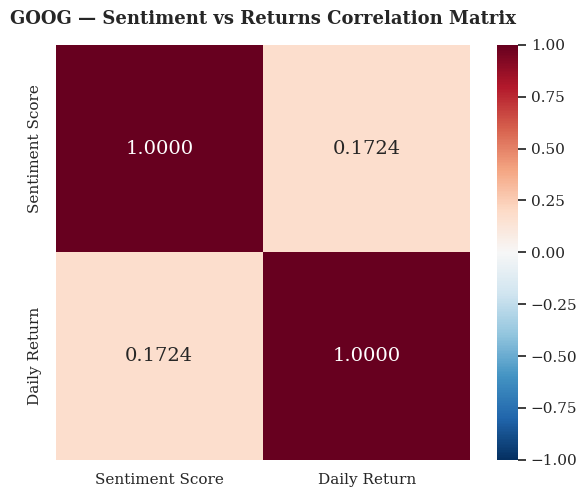

✅ Correlation heatmap rendered!


In [12]:
# Correlation heatmap
corr_matrix = merged_df[['compound', 'daily_return']].corr(
    method='pearson')
corr_matrix.index   = ['Sentiment Score', 'Daily Return']
corr_matrix.columns = ['Sentiment Score', 'Daily Return']

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, fmt='.4f',
            annot_kws={"size": 14})
plt.title('GOOG — Sentiment vs Returns Correlation Matrix',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("✅ Correlation heatmap rendered!")

### 9.2 Scatter Plot — Sentiment vs Returns

The scatter plot below shows the relationship between daily sentiment
scores and daily stock returns, annotated with the Pearson correlation
coefficient and a regression line.

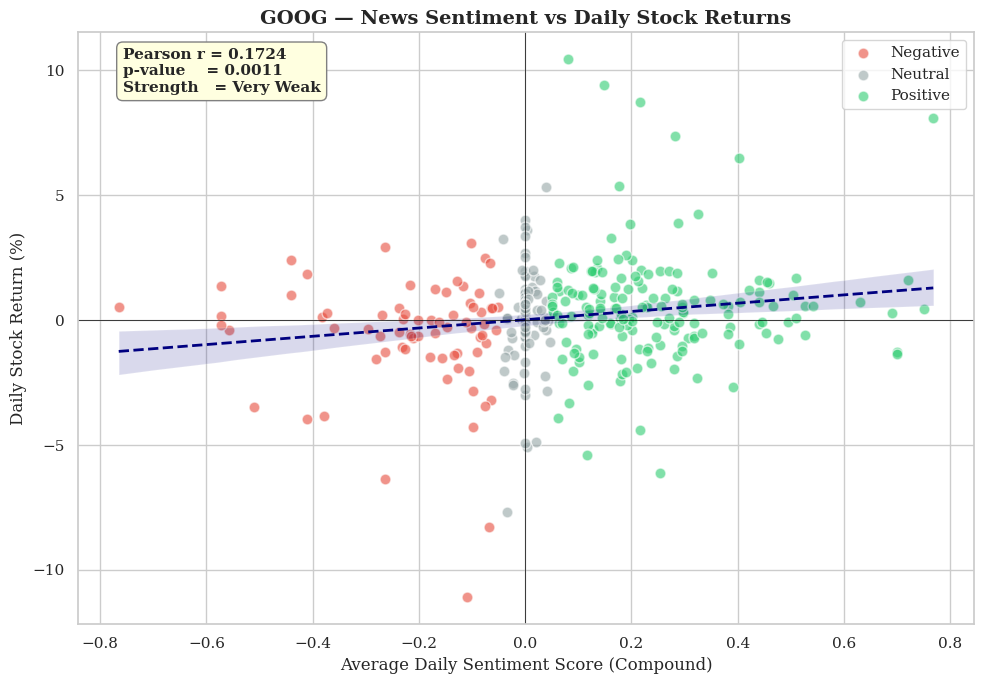

✅ Scatter plot rendered!


In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}

for label, group in merged_df.groupby('sentiment_label'):
    ax.scatter(group['compound'], group['daily_return'],
               c=colors_map[label], label=label,
               alpha=0.6, s=60, edgecolors='white')

# Regression line
sns.regplot(x='compound', y='daily_return', data=merged_df,
            scatter=False, ax=ax, color='navy',
            line_kws={'linewidth': 2, 'linestyle': '--'})

# Annotate
ax.annotate(
    f'Pearson r = {corr:.4f}\np-value    = {pval:.4f}\n'
    f'Strength   = {strength}',
    xy=(0.05, 0.90), xycoords='axes fraction',
    fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='lightyellow', edgecolor='gray'))

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('GOOG — News Sentiment vs Daily Stock Returns',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Daily Sentiment Score (Compound)',
              fontsize=12)
ax.set_ylabel('Daily Stock Return (%)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Scatter plot rendered!")

### 9.3 Average Daily Return by Sentiment Category

The bar chart below shows the average daily stock return for each
sentiment category, revealing whether positive news days are
associated with higher returns.

=== Average Daily Return by Sentiment Category ===
sentiment_label  avg_return  count      std
       Negative   -0.652804     73 2.303081
        Neutral    0.079639    109 1.805490
       Positive    0.519924    171 2.191035


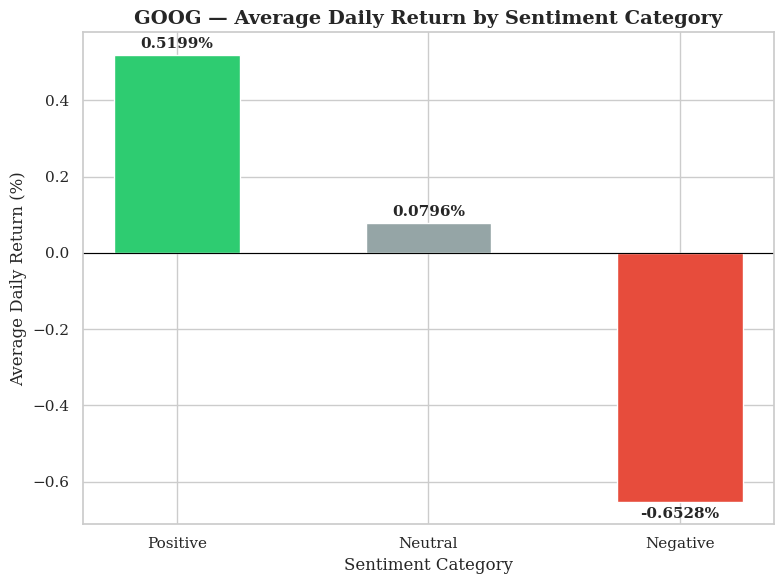

✅ Bar chart rendered!


In [14]:
# Average return per sentiment category
category_returns = merged_df.groupby(
    'sentiment_label')['daily_return'].agg(
    ['mean', 'count', 'std']).reset_index()
category_returns.columns = ['sentiment_label', 'avg_return',
                             'count', 'std']

print("=== Average Daily Return by Sentiment Category ===")
print(category_returns.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))

colors_bar = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}

# Ensure consistent order
order = ['Positive', 'Neutral', 'Negative']
cat_ordered = category_returns.set_index(
    'sentiment_label').reindex(order).reset_index()
cat_ordered = cat_ordered.dropna()

bars = ax.bar(
    cat_ordered['sentiment_label'],
    cat_ordered['avg_return'],
    color=[colors_bar[s] for s in cat_ordered['sentiment_label']],
    edgecolor='white', width=0.5)

for bar, val in zip(bars, cat_ordered['avg_return']):
    offset = 0.01 if val >= 0 else -0.05
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{val:.4f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('GOOG — Average Daily Return by Sentiment Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Average Daily Return (%)', fontsize=12)
plt.tight_layout()
plt.show()
print("✅ Bar chart rendered!")

### 9.4 Sentiment Score & Stock Return Over Time

The time series chart shows how daily sentiment scores and daily
stock returns move together over the analysis period.

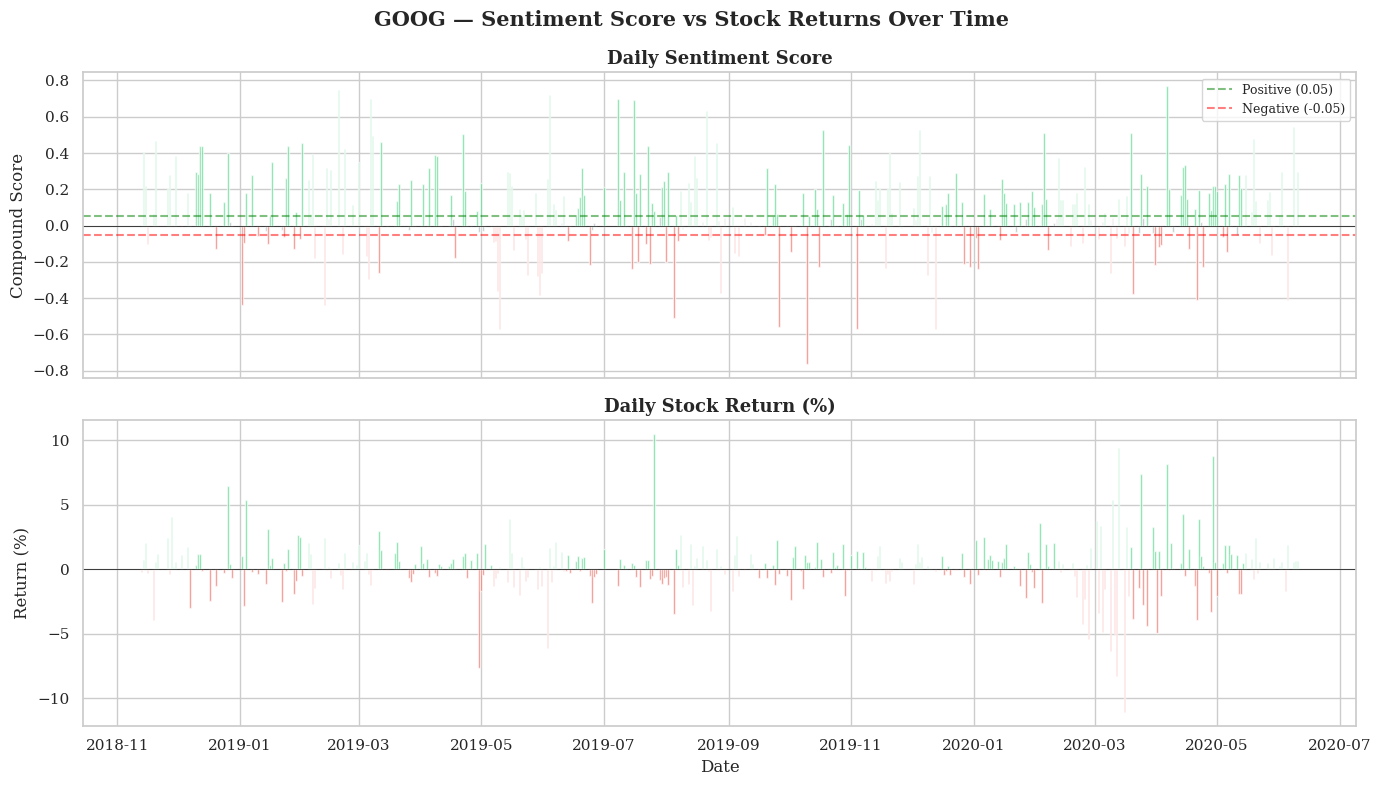

✅ Time series plot rendered!


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Sentiment over time
axes[0].bar(merged_df['trading_date'], merged_df['compound'],
            color=['#2ecc71' if v >= 0.05
                   else '#e74c3c' if v <= -0.05
                   else '#95a5a6'
                   for v in merged_df['compound']],
            alpha=0.7)
axes[0].axhline(0.05,  color='green', linestyle='--',
                alpha=0.5, label='Positive (0.05)')
axes[0].axhline(-0.05, color='red',   linestyle='--',
                alpha=0.5, label='Negative (-0.05)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Daily Sentiment Score',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Compound Score')
axes[0].legend(fontsize=9)

# Returns over time
axes[1].bar(merged_df['trading_date'], merged_df['daily_return'],
            color=['#2ecc71' if v >= 0 else '#e74c3c'
                   for v in merged_df['daily_return']],
            alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Daily Stock Return (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Return (%)')
axes[1].set_xlabel('Date')

plt.suptitle('GOOG — Sentiment Score vs Stock Returns Over Time',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series plot rendered!")

## 10. Key Findings & Summary

In [16]:
print("=" * 55)
print("   GOOG SENTIMENT CORRELATION — KEY FINDINGS")
print("=" * 55)

print(f"""
📰 ANALYSIS OVERVIEW
- Total articles analyzed     : {len(goog_news_scored)}
- Trading days matched        : {len(merged_df)}
- Date range                  : {merged_df['trading_date'].min().date()} to {merged_df['trading_date'].max().date()}

😊 SENTIMENT SUMMARY
- Average compound score      : {goog_news_scored['compound'].mean():.4f}
- Positive articles           : {(goog_news_scored['sentiment_label'] == 'Positive').sum()}
- Neutral articles            : {(goog_news_scored['sentiment_label'] == 'Neutral').sum()}
- Negative articles           : {(goog_news_scored['sentiment_label'] == 'Negative').sum()}

📈 CORRELATION RESULTS
- Pearson  r = {corr_results['pearson']['r']:+.4f}  p = {corr_results['pearson']['p']:.4f}  {'✅ Significant' if corr_results['pearson']['p'] < 0.05 else '❌ Not Significant'}
- Spearman r = {corr_results['spearman']['r']:+.4f}  p = {corr_results['spearman']['p']:.4f}  {'✅ Significant' if corr_results['spearman']['p'] < 0.05 else '❌ Not Significant'}
- Kendall  r = {corr_results['kendall']['r']:+.4f}  p = {corr_results['kendall']['p']:.4f}  {'✅ Significant' if corr_results['kendall']['p'] < 0.05 else '❌ Not Significant'}

- Pearson Strength            : {strength}
- Pearson Direction           : {direction}

📊 AVERAGE RETURNS BY SENTIMENT
""")
for _, row in cat_ordered.iterrows():
    print(f"  {row['sentiment_label']:10} : {row['avg_return']:.4f}% "
          f"(n={int(row['count'])})")

print("\n" + "=" * 55)

   GOOG SENTIMENT CORRELATION — KEY FINDINGS

📰 ANALYSIS OVERVIEW
- Total articles analyzed     : 1199
- Trading days matched        : 353
- Date range                  : 2018-11-13 to 2020-06-10

😊 SENTIMENT SUMMARY
- Average compound score      : 0.0805
- Positive articles           : 423
- Neutral articles            : 560
- Negative articles           : 216

📈 CORRELATION RESULTS
- Pearson  r = +0.1724  p = 0.0011  ✅ Significant
- Spearman r = +0.1710  p = 0.0013  ✅ Significant
- Kendall  r = +0.1170  p = 0.0012  ✅ Significant

- Pearson Strength            : Very Weak
- Pearson Direction           : Positive

📊 AVERAGE RETURNS BY SENTIMENT

  Positive   : 0.5199% (n=171)
  Neutral    : 0.0796% (n=109)
  Negative   : -0.6528% (n=73)



## 11. Interpretation & Conclusion

**Correlation Interpretation:**
GOOG shows a **very weak but statistically significant positive relationship** between news sentiment and same-day stock returns, with a Pearson coefficient of **+0.1724 (p=0.0011)**. The result is confirmed by all three methods (Spearman: +0.1710, p=0.0013; Kendall: +0.1170, p=0.0012). The key distinction for GOOG is that the **statistical significance is achieved** — unlike AAPL and AMZN — thanks to the much larger sample of **353 matched trading days** covering November 2018 to June 2020.

**Sentiment Category Analysis:**
The bar chart shows a consistent pattern across all three categories — positive sentiment days averaged **+0.52% returns**, neutral days **+0.08%**, and negative sentiment days **-0.65%**. The monotonic decrease from positive to negative confirms the directional hypothesis. While the magnitude of differences is smaller than FB, the pattern is statistically reliable due to the larger sample size.

**Investment Implication:**
The statistical significance achieved for GOOG — even with a very weak coefficient — demonstrates that with sufficient data, sentiment signals can provide consistent directional guidance. The relationship is subtle but real: positive news days are systematically associated with above-average returns, and negative news days with below-average returns. This is consistent with Alphabet's large institutional investor base, which tends to react more gradually and rationally to news compared to retail-heavy stocks.

**Limitations:**
- While statistically significant, the **very weak coefficient (+0.17)** means sentiment explains only about **3% of the variance** in daily returns — the vast majority of price movement is driven by other factors
- The **18-month date range** for GOOG is longer than other companies but still covers a specific macroeconomic period including US-China trade tensions and COVID-19 onset
- **Headline-only analysis** for a company as large as Alphabet likely misses significant market-moving information contained in full article text, analyst reports, and earnings guidance